In [4]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [ ]:
using Symbolics
using LinearAlgebra

# Define symbolic parameters
@variables a b r
@variables i j

"""
    construct_symbolic_matrix(N, a, b, r)

Construct an N×N symbolic matrix where diagonal elements are a√(2i+r)√(2j+r)
and off-diagonal elements are b√(2i+r)√(2j+r).

Parameters (symbolic):
- a: coefficient for diagonal elements
- b: coefficient for off-diagonal elements  
- r: parameter in the square root terms
- N: matrix dimension (must be numeric)
"""
function construct_symbolic_matrix(N::Int, a, b, r)
    M = zeros(Num, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2i + r)  sqrt(2j + r)
            if i == j
                M[i, j] = a  coeff
            else
                M[i, j] = b  coeff
            end
        end
    end
    
    return M
end

# Construct the matrix with symbolic parameters
N = 10
M_symbolic = construct_symbolic_matrix(N, a, b, r)

println("Symbolic Matrix M (first 4×4 block):")
println(M_symbolic[1:4, 1:4])
println("\nFull symbolic matrix dimensions: $(size(M_symbolic))")

# Display some entries to show the structure
println("\nDiagonal entry M[1,1] = ", M_symbolic[1, 1])
println("Off-diagonal entry M[1,2] = ", M_symbolic[1, 2])
println("Diagonal entry M[2,2] = ", M_symbolic[2, 2])

Symbolic Matrix M (first 4×4 block):
Num[a*(sqrt(2 + r)^2) b*sqrt(4 + r)*sqrt(2 + r) b*sqrt(6 + r)*sqrt(2 + r) b*sqrt(8 + r)*sqrt(2 + r); b*sqrt(4 + r)*sqrt(2 + r) a*(sqrt(4 + r)^2) b*sqrt(6 + r)*sqrt(4 + r) b*sqrt(8 + r)*sqrt(4 + r); b*sqrt(6 + r)*sqrt(2 + r) b*sqrt(6 + r)*sqrt(4 + r) a*(sqrt(6 + r)^2) b*sqrt(8 + r)*sqrt(6 + r); b*sqrt(8 + r)*sqrt(2 + r) b*sqrt(8 + r)*sqrt(4 + r) b*sqrt(8 + r)*sqrt(6 + r) a*(sqrt(8 + r)^2)]

Full symbolic matrix dimensions: (10, 10)

Diagonal entry M[1,1] = a*(sqrt(2 + r)^2)
Off-diagonal entry M[1,2] = b*sqrt(4 + r)*sqrt(2 + r)
Diagonal entry M[2,2] = a*(sqrt(4 + r)^2)


In [15]:
using Symbolics
using LinearAlgebra

# Define symbolic parameters
@variables a b r λ

"""
    construct_symbolic_matrix(N, a, b, r)

Construct an N×N symbolic matrix.
"""
function construct_symbolic_matrix(N::Int, a, b, r)
    M = zeros(Num, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2i + r) *sqrt(2j + r)
            if i == j
                M[i, j] = a * coeff
            else
                M[i, j] = b * coeff
            end
        end
    end
    
    return M
end


N = 2
M = construct_symbolic_matrix(N, a, b, r)

println("\nMatrix M:")
for i in 1:N
    println(M[i, :])
end


I_sym = Num.(Matrix(I, N, N))
char_matrix = M .- λ * I_sym
char_poly = det(char_matrix)

println("\nCharacteristic polynomial (unsimplified):")
println(char_poly)

# Simplify
char_poly_simplified = simplify(char_poly)
println("\nCharacteristic polynomial (simplified):")
println(char_poly_simplified)



try
    eigenvalues = solve(char_poly_simplified, λ)
    println("\n✓ Eigenvalues found!\n")
    for (i, eig) in enumerate(eigenvalues)
        println("λ[$i] = ")
        display(eig)
        println()
    end
catch e
    println("\n✗ Error solving: $e")
    println("\nCharacteristic polynomial to solve:")
    println(char_poly_simplified, " = 0")
end


N = 3
M = construct_symbolic_matrix(N, a, b, r)

println("\nMatrix M:")
for i in 1:N
    println(M[i, :])
end

println("\nComputing characteristic polynomial...")
I_sym = Num.(Matrix(I, N, N))
char_matrix = M .- λ * I_sym
char_poly = det(char_matrix)
char_poly_simplified = simplify(char_poly)

println("\nCharacteristic polynomial (simplified):")
println(char_poly_simplified)

try
    println("\nAttempting to solve for eigenvalues...")
    eigenvalues = solve(char_poly_simplified, λ)
    println("\n✓ Eigenvalues found!")
    for (i, eig) in enumerate(eigenvalues)
        println("λ[$i] = ", eig)
    end
catch e
    println("\n✗ Cannot solve symbolically: $e")
    println("(This is expected for cubic and higher degree polynomials)")
end


Matrix M:
Num[a*(sqrt(2 + r)^2), b*sqrt(4 + r)*sqrt(2 + r)]
Num[b*sqrt(4 + r)*sqrt(2 + r), a*(sqrt(4 + r)^2)]

Characteristic polynomial (unsimplified):
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2)

Characteristic polynomial (simplified):
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2)

✗ Error solving: UndefVarError(:solve, Main)

Characteristic polynomial to solve:
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2) = 0

Matrix M:
Num[a*(sqrt(2 + r)^2), b*sqrt(4 + r)*sqrt(2 + r), b*sqrt(6 + r)*sqrt(2 + r)]
Num[b*sqrt(4 + r)*sqrt(2 + r), a*(sqrt(4 + r)^2), b*sqrt(6 + r)*sqrt(4 + r)]
Num[b*sqrt(6 + r)*sqrt(2 + r), b*sqrt(6 + r)*sqrt(4 + r), a*(sqrt(6 + r)^2)]

Computing characteristic polynomial...

Characteristic polynomial (simplified):
((-λ + a*(sqrt(6 + r)^2))*(-λ + a*(sqrt(4 + r)^2)) - (b^2)*(sqrt(6 + r)^2)*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) + ((λ - 

In [8]:
(1000000000000+1)^(0.000001)

1.000027631402856

In [21]:

N_values=LinRange(1,100,100)
gamma_values=LinRange(1,100,100)

result=zeros(Float64, 100, 100)

for i in 1:100
    for j in 1:100

        if ((i/(i-1))^(j))-(1+(j/(i-1)))<1e-5
             
            result[i,j]=1
        else
          
            result[i,j]=0
        end

    end
    
end    



display(result)

100×100 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

Test for scaling of eta

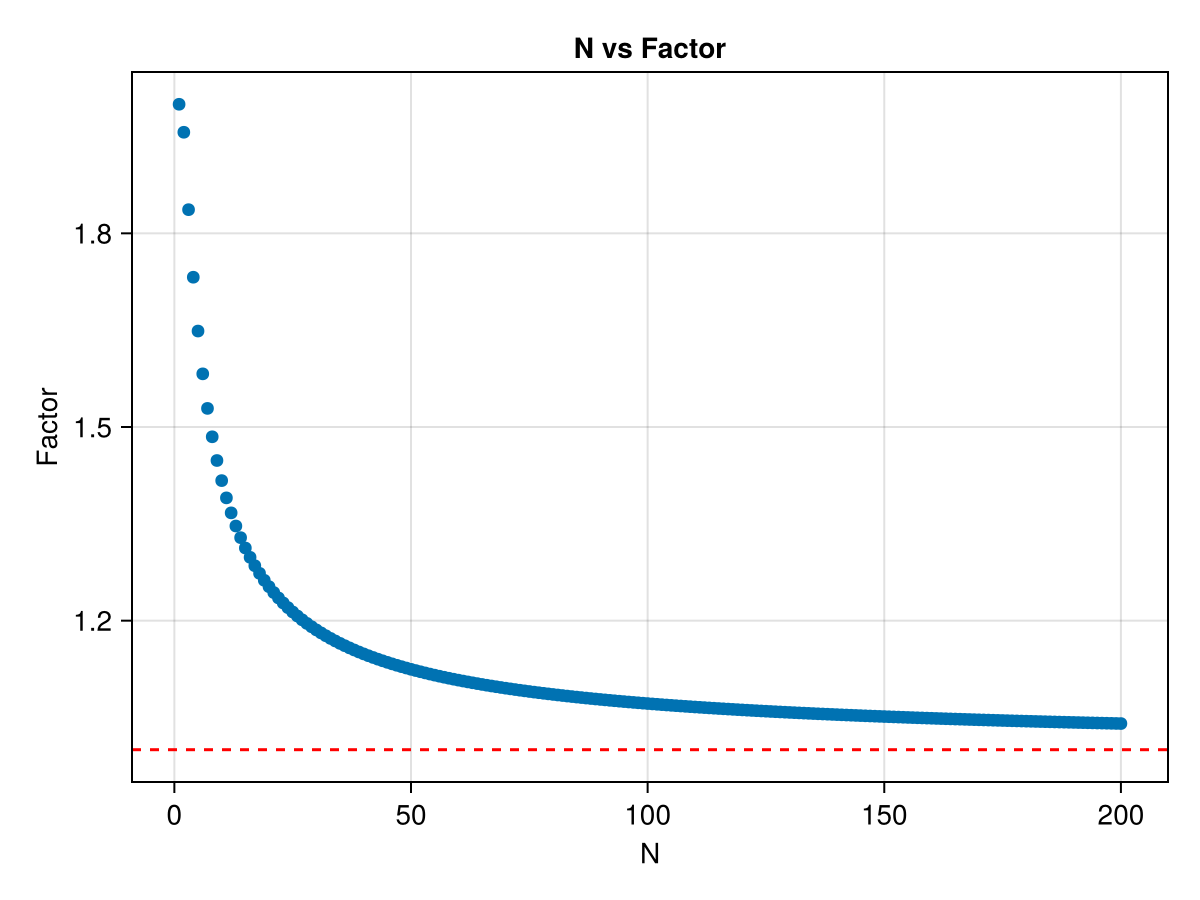

In [ ]:
using CairoMakie

N_values=LinRange(1,200,200)

factors=zeros(Float64, 200)

for (i, n) in enumerate(N_values)
    factors[i] = (1+n*n)^(1/n)
end


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Factor", title="N vs Factor")
scatter!(ax, N_values, factors)
hlines!(ax, 1, color=:red, linestyle=:dash, label="1")
fig

Trial for eigenvalue expression

In [40]:
N=100
r= 0

B=1 #B=b^2
A=1.1
#A=(1+1/N)*B      #A=a^2


1.1

In [41]:
eigen=[]
det_analytical=1.0
for i in 1:N
    eigenvalue =(2)^(1/(N-1))*(A-B)*(2i + r)

    if i==N
       eigenvalue =(1/2)*(1+B*N/(A-B))*(A-B)*(2i + r)
    end

    det_analytical*=eigenvalue
    push!(eigen, eigenvalue)
end
display(det_analytical)
display(eigen[N])
display(eigen)

1.1842333805758106e91

10010.0

100-element Vector{Any}:
     0.2014052108767
     0.4028104217534
     0.6042156326301
     0.8056208435068
     1.0070260543835
     1.2084312652602
     1.4098364761369
     1.6112416870136
     1.8126468978902999
     2.014052108767
     2.2154573196436997
     2.4168625305204
     2.6182677413971
     ⋮
    17.9250637680263
    18.126468978903
    18.3278741897797
    18.5292794006564
    18.7306846115331
    18.9320898224098
    19.1334950332865
    19.3349002441632
    19.536305455039898
    19.737710665916598
    19.9391158767933
 10010.0

In [42]:
M = zeros(Float64, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2i + r) *sqrt(2j + r)
            if i == j
                M[i, j] = (A/B) * coeff
            else
                M[i, j] =coeff
            end
        end
    end

eigenvalues_real = eigvals(Matrix(B*M))    

determinant_real = (det(Matrix(B*M)))


1.1842333805758124e91

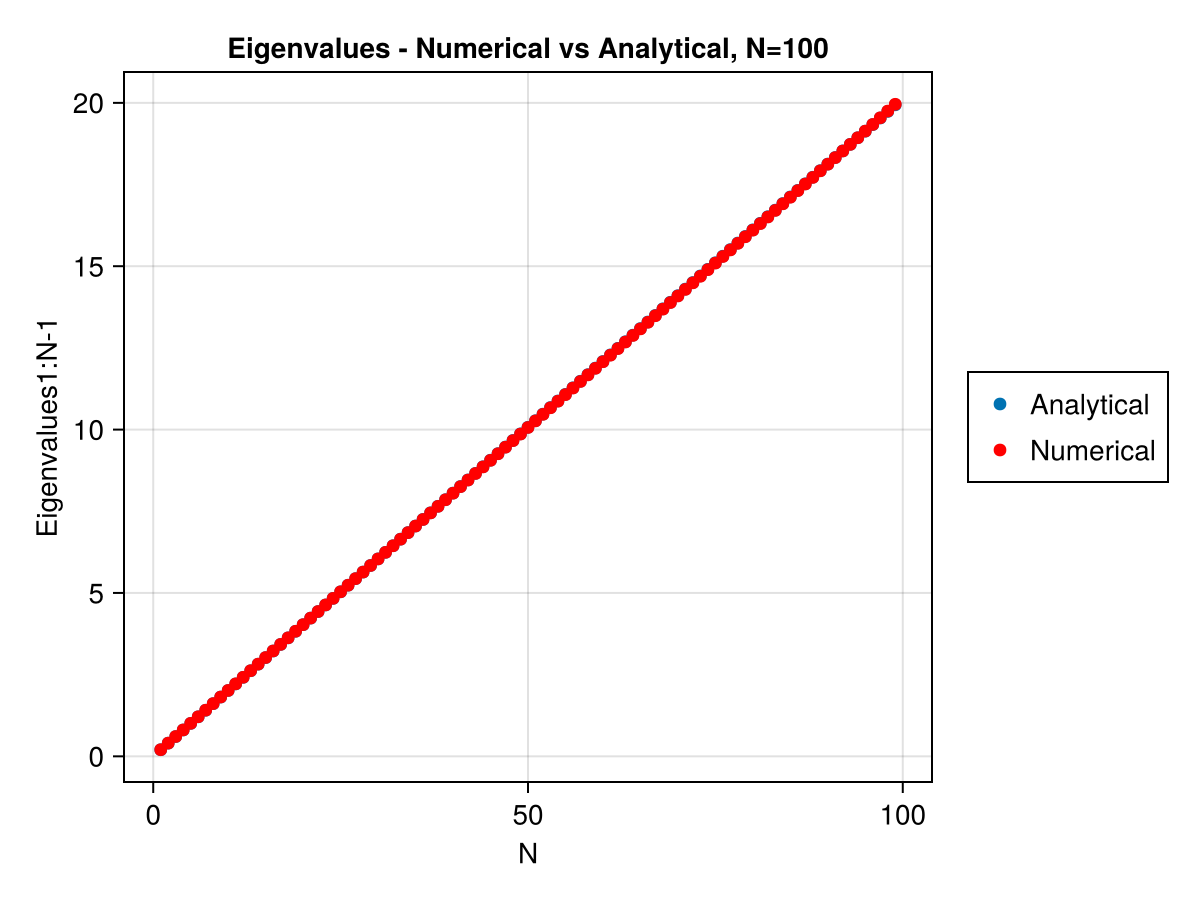

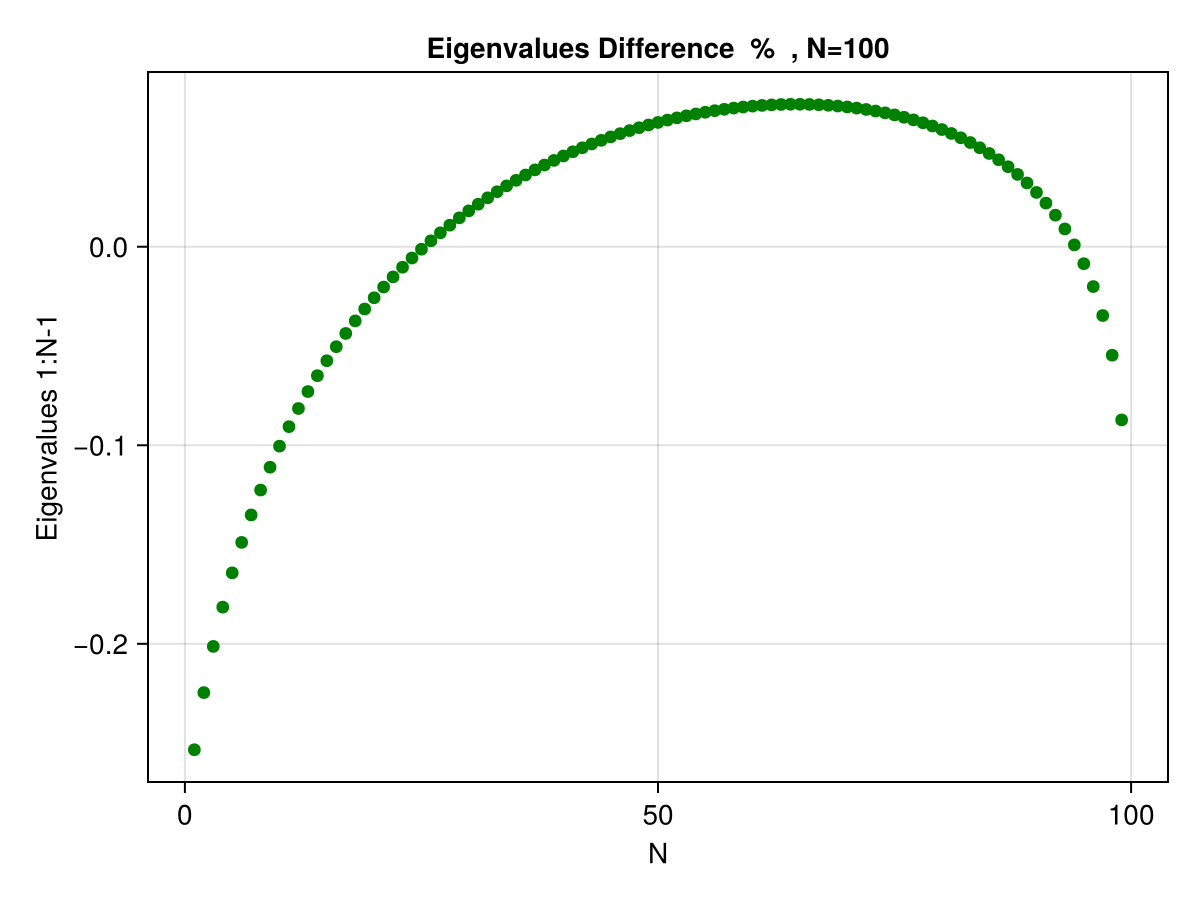

CairoMakie.Screen{IMAGE}


In [43]:
using CairoMakie

N_values=LinRange(1,N,N)


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Eigenvalues1:N-1", title="Eigenvalues - Numerical vs Analytical, N=$N")
scatter!(ax, N_values[1:N-1], eigen[1:N-1], label="Analytical")
scatter!(ax, N_values[1:N-1], eigenvalues_real[1:N-1], color=:red, label="Numerical")

Legend(fig[1, 2], ax)
#save("/home/sofialon/Newtrinos.jl/plots_NP/eigenvalues_comp_N$(N).png", fig)
display(fig)



fig1 = Figure()
ax = Axis(fig1[1, 1], xlabel="N", ylabel="Eigenvalues 1:N-1", title="Eigenvalues Difference  %  , N=$N")
scatter!(ax, N_values[1:N-1], 100*(eigen[1:N-1].-eigenvalues_real[1:N-1])./eigenvalues_real[1:N-1], color=:green, label="Numerical- Analytical")
        #save("/home/sofialon/Newtrinos.jl/plots_NP/eigenvalues_res_N$(N).png", fig)
 display(fig1)

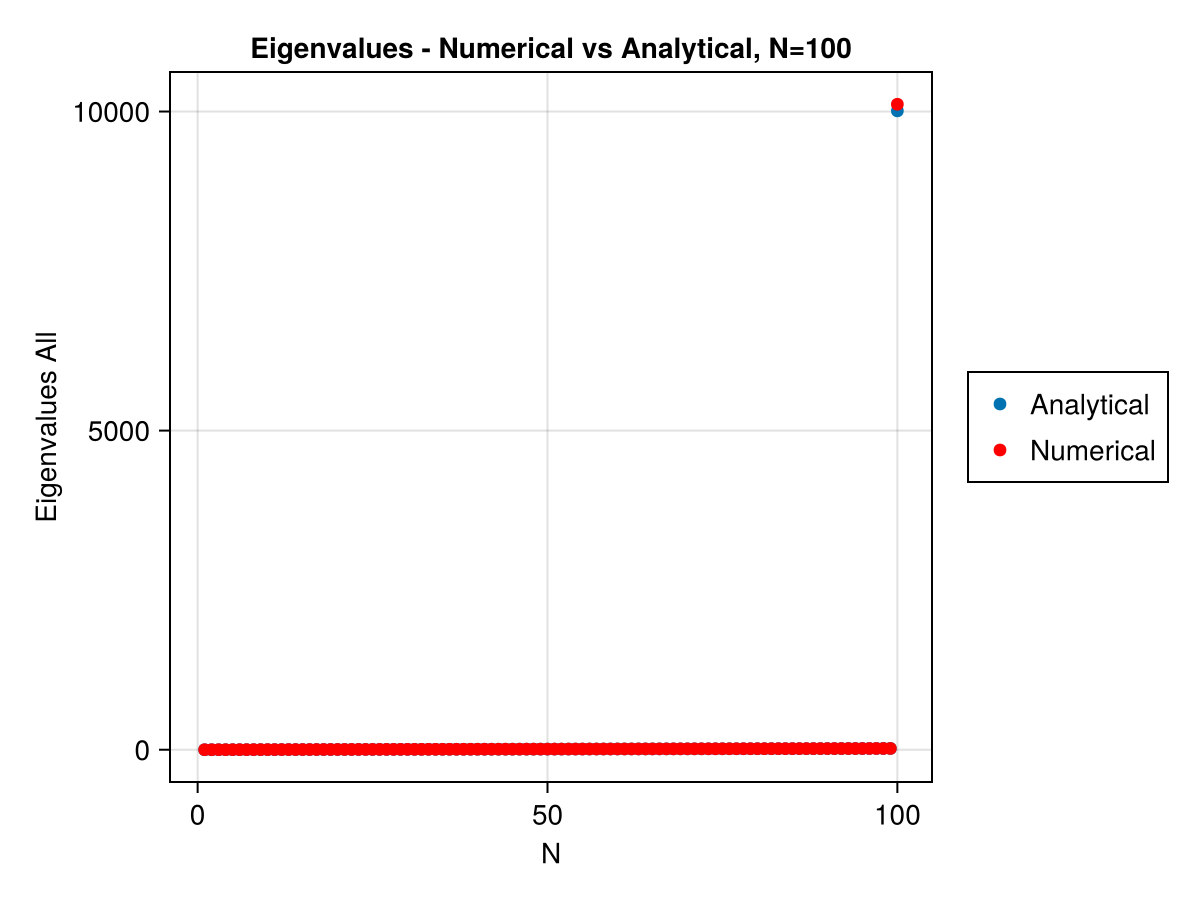

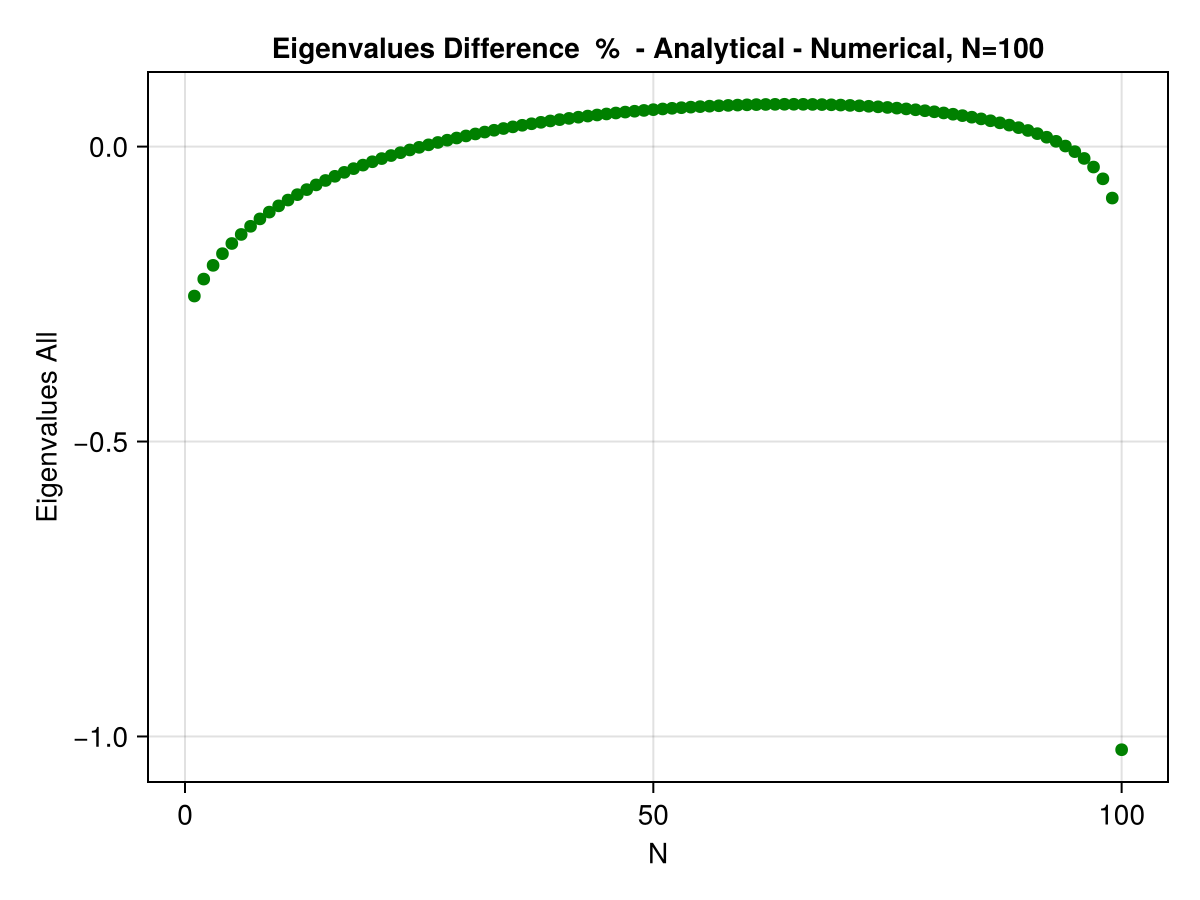

CairoMakie.Screen{IMAGE}


In [44]:


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Eigenvalues All", title="Eigenvalues - Numerical vs Analytical, N=$N")
scatter!(ax, N_values, eigen, label="Analytical")
scatter!(ax, N_values, eigenvalues_real, color=:red, label="Numerical")

Legend(fig[1, 2], ax)
#save("/home/sofialon/Newtrinos.jl/plots_NP/eigenvalues_comp_N$(N)_N.png", fig)
display(fig)



fig1 = Figure()
ax = Axis(fig1[1, 1], xlabel="N", ylabel="Eigenvalues All", title="Eigenvalues Difference  %  - Analytical - Numerical, N=$N")
scatter!(ax, N_values, 100*(eigen.-eigenvalues_real)./eigenvalues_real, color=:green, label="Numerical- Analytical")
#save("/home/sofialon/Newtrinos.jl/plots_NP/eigenvalues_res_N$(N)_N.png", fig1)
display(fig1)